# Project: Chest X-ray classification (Pneumonia vs Normal)

**Author:** Jan Nowojski


## 1. Project description
The goal of the project is to create and train a machine learning model capable of automatic classification of chest X-ray images into two diagnostic classes:
* **NORMAL:** Healthy patient
* **PNEUMONIA:** Patient with pneumonia

The project could be used to help doctors filter X-ray images

## 2. Mathematical problem formulation
The problem is defined as a binary classification task in supervised learning

Let $\mathcal{X}$ be the space of input images (represented as tensors with dimensions $C \times H \times W$), and $\mathcal{Y} = \{0, 1\}$ be the set of labels, where:
* $y=0$ denotes the *NORMAL* class,
* $y=1$ denotes the *PNEUMONIA* class.

The goal is to find a parametric function $f_\theta: \mathcal{X} \to [0, 1]$, represented by a neural network with weights $\theta$, which approximates the conditional probability of disease occurrence for a given image $x$:

$$P(Y=1 | X=x) \approx f_\theta(x)$$

The classification decision $y$ is made based on the decision threshold ($0.5$):

$$
y = \begin{cases} 
1 & \text{if } f_\theta(x) > 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

## 3. Input data and preprocessing

**Data source:**
The *Chest X-Ray Images (Pneumonia)* dataset from the Kaggle platform was used.

**Dataset structure:**
The data was divided into three subsets:
1. **Training set:** Used to optimize model parameters (5216 images).
2. **Test/validation set:** Used to evaluate the model on unseen data (624 images).

**Data preparation (Preprocessing):**
Each input image $x$ undergoes a transformation $T(x)$ to fit the network requirements:
* **Resize:** Scaling to $224 \times 224$ pixels.
* **Augmentation (training only):** Random horizontal flips (*RandomHorizontalFlip*) and slight rotations (*RandomRotation*) to prevent overfitting.
* **Normalization:** Standardization of pixel values using the mean and standard deviation from the ImageNet dataset:
    * Mean: $[0.485, 0.456, 0.406]$
    * Std: $[0.229, 0.224, 0.225]$

## 4. Algorithm and architecture description

The **Transfer Learning** method with the **ResNet18** (Residual Network) architecture was applied in the project.

**Why ResNet?** Traditional deep neural networks suffer from the vanishing gradient problem. ResNet introduces residual connections (skip connections), which allow the signal to flow while bypassing certain layers.

Mathematically, a residual block can be expressed as:
$$y = \sigma(\mathcal{F}(x, \{W_i\}) + x)$$

Where:
* $x$ is the block input.
* $y$ is the block output.
* $\mathcal{F}$ is the function implemented by convolutional layers (weights).
* $\sigma$ is a non-linear activation function (ReLU).

**Loss Function:** To optimize the model, the **Binary Cross-Entropy Loss** function was used, which penalizes the model for incorrect confidence predictions:
$$L(\theta) = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$.

**Optimization algorithm:** The **Adam** (Adaptive Moment Estimation) algorithm was used, which dynamically adjusts the learning rate for each parameter.

## 5.Results and conclusions

The training process over 3 epochs is presented below. The plots show the Loss value and Accuracy for the training and validation sets.

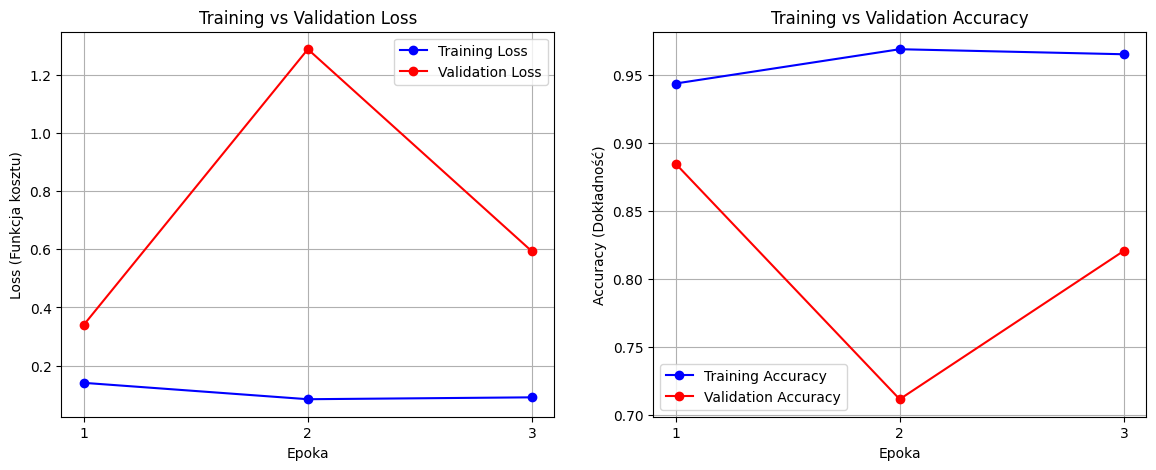

In [2]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]
train_loss = [0.1404, 0.0840, 0.0905]
val_loss = [0.3395, 1.2884, 0.5925]

train_acc = [0.9434, 0.9686, 0.9649]
val_acc = [0.8846, 0.7115, 0.8205]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss, 'bo-', label='Training Loss')
ax1.plot(epochs, val_loss, 'ro-', label='Validation Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Loss (Funkcja kosztu)')
ax1.set_xticks(epochs)
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
ax2.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Accuracy (Dokładność)')
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True)
plt.savefig('wyniki_szkolenia.png', dpi=300, bbox_inches='tight')
plt.show()

### Result analysis for 3 epochs:

1. **Accuracy:** The model reached its highest accuracy on the validation set as early as the **1st epoch** (Accuracy: ~88%, Loss: 0.34). This is a very good result, confirming the effectiveness of the Transfer Learning method.
2. **Overfitting:** In the 2nd epoch, we observe a drastic increase in `Validation Loss` (up to 1.28) with a simultaneous decrease in `Training Loss`. This means the model began to "memorize" the specifics of the training set, losing its ability to generalize.
3. **Final conclusions:**
    * The use of a pre-trained ResNet18 network allowed for achieving high accuracy quickly.
    * Due to the small size of the validation set and rapid overfitting, the optimal point to stop training (Early Stopping) is the 1st epoch.
    * The model correctly differentiates between healthy lung images and those with pneumonia.

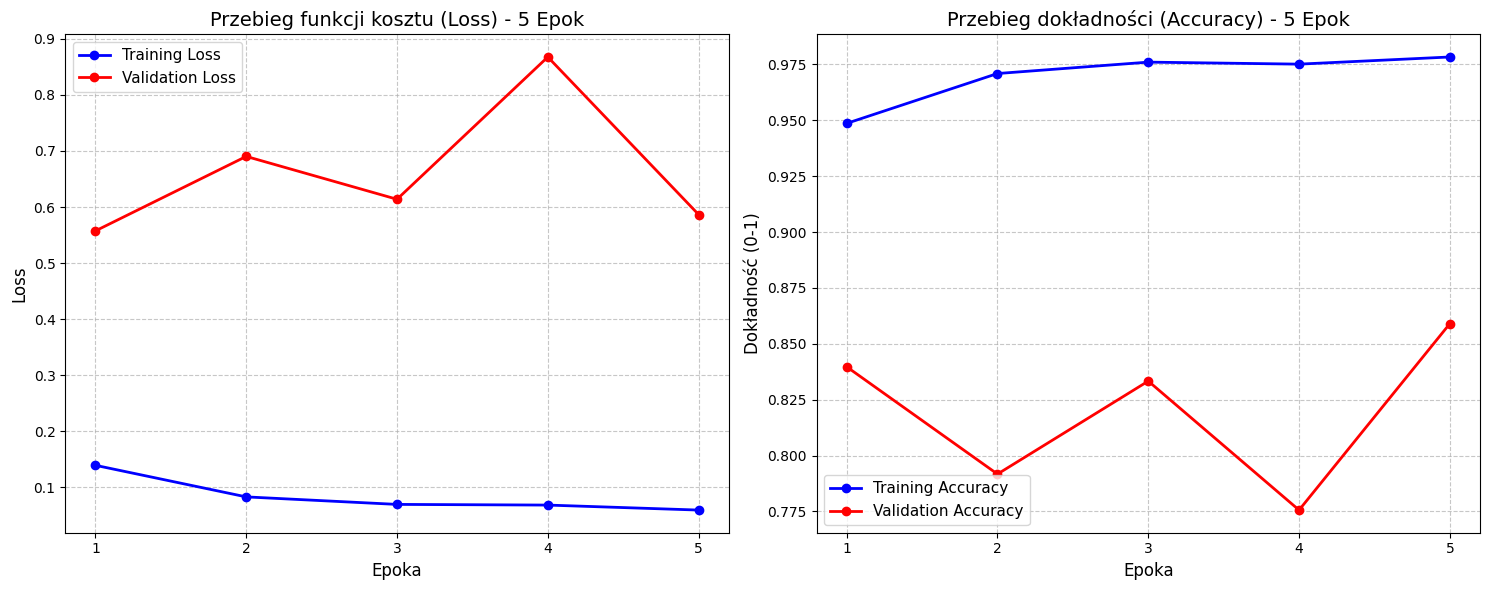

In [4]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

train_loss = [0.1395, 0.0832, 0.0698, 0.0686, 0.0597]
train_acc  = [0.9486, 0.9709, 0.9760, 0.9751, 0.9783]

val_loss = [0.5575, 0.6903, 0.6139, 0.8676, 0.5867]
val_acc  = [0.8397, 0.7917, 0.8333, 0.7756, 0.8590]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(epochs, train_loss, 'bo-', label='Training Loss', linewidth=2)
ax1.plot(epochs, val_loss, 'ro-', label='Validation Loss', linewidth=2)
ax1.set_title('Przebieg funkcji kosztu (Loss) - 5 Epok', fontsize=14)
ax1.set_xlabel('Epoka', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=11)

ax2.plot(epochs, train_acc, 'bo-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, val_acc, 'ro-', label='Validation Accuracy', linewidth=2)
ax2.set_title('Przebieg dokładności (Accuracy) - 5 Epok', fontsize=14)
ax2.set_xlabel('Epoka', fontsize=12)
ax2.set_ylabel('Dokładność (0-1)', fontsize=12)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=11)

best_epoch = 5
best_acc = val_acc[4]


plt.tight_layout()
plt.savefig('wyniki_5_epok.png') 
plt.show()

### Analiza wyników (Eksperyment 5 epok):

1. **Niestabilność treningu:** W przeciwieństwie do krótszego treningu, tutaj obserwujemy zjawisko silnych fluktuacji . W **4. epoce** nastąpiło gwałtowne załamanie wyników – `Validation Accuracy` spadło do **77%**, a `Loss` wyraźnie wzrósł. Wskazuje to na wrażliwość modelu na dobór batchy przy tak małym zbiorze danych.

2. **Powrót zbieżności :** W **5. epoce** model zdołał wyjść z lokalnego minimum. Skuteczność walidacyjna wzrosła do najwyższego poziomu w całym eksperymencie (**85.9%**), a funkcja kosztu spadła do poziomu początkowego.

3. **Wnioski końcowe:**
    * Wydłużenie treningu pozwoliło osiągnąć **lepszy wynik końcowy** niż w wariancie 3-epokowym.


## 6. Instrukcja replikacji wyników

Aby uruchomić projekt i zreplikować wyniki:

1.  Zainstaluj zależności:
    `pip install -r requirements.txt`
2.  Pobierz dane :
    `python scripts/download_data.py`
3.  Uruchom trening:
    `python scripts/train.py`
4.  Przetestuj na pojedynczym zdjęciu:
    `python scripts/infer.py data/samples/NORMAL.jpeg`